# Selfing-rate likelihoods for fixed samples

Compare **20, 50, and 100 diploid individuals** sampled from populations of **N=100, 250, and 500**. Within each simulated population, samples are nested (20 ⊂ 50 ⊂ 100), and the same individuals are used at every locus.

There are 20 simulated selfing rates, 0–0.95 in steps of 0.05, and one population per rate/census combination. Each population has 10,000 loci of 1,000 bp, a burn-in of 10 × census size generations, mutation rate 1e-7 per base per generation, within-locus recombination 5e-8, and between-locus recombination 0.5. Loci share the population pedigree. The conditional, unfolded DGS likelihood is evaluated on the same 0–0.95 candidate grid.

This notebook reads the saved likelihoods and produces the figure; it does not rerun simulations or fits. Each heatmap row is a single population realization, not an average over replicates. At N=100, n=100 samples the entire population.

**To regenerate the data:** `run_study.py` runs the local `fixed_individuals.slim` model and fits all three nested samples using an installed `selfdgs` package. See [README.md](README.md) for sequential and Slurm instructions. This plotting notebook uses only the resulting CSV.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Run from this notebook's directory or the project root.
HERE = Path.cwd()
if not (HERE / "results/likelihoods.csv").exists():
    HERE = HERE / "dgs_manuscript/validation/fixed_individuals"

RESULTS = HERE / "results"
SAMPLE_SIZES = [20, 50, 100]
POPULATION_SIZES = [100, 250, 500]
SELFING_GRID = np.round(np.arange(20) * 0.05, 12)
CLIP_FLOOR = -200.0  # Change this to adjust the displayed likelihood range.

likelihoods = pd.read_csv(RESULTS / "likelihoods.csv")
likelihoods[["true_s", "candidate_s"]] = likelihoods[["true_s", "candidate_s"]].round(12)

# Require exactly the manuscript design before drawing any panels.
expected = pd.MultiIndex.from_product(
    [POPULATION_SIZES, SAMPLE_SIZES, SELFING_GRID, SELFING_GRID],
    names=["census_size", "n_diploids", "true_s", "candidate_s"],
)
actual = pd.MultiIndex.from_frame(likelihoods[list(expected.names)])
if (actual.has_duplicates or len(actual) != len(expected)
        or len(expected.difference(actual)) or len(actual.difference(expected))
        or not np.isfinite(likelihoods["loglik"]).all()
        or not likelihoods["replicate"].eq(0).all()
        or not likelihoods["n_loci"].eq(10000).all()):
    raise ValueError("Expected 3,600 finite likelihoods for the complete manuscript grid")

# Normalize separately for each dataset; clipping is applied only when plotting.
keys = ["census_size", "n_diploids", "true_s"]
likelihoods["delta_loglik"] = (
    likelihoods["loglik"] - likelihoods.groupby(keys)["loglik"].transform("max")
)


## Likelihood heatmap

Columns are census sizes; rows are sample sizes. Within each panel, the horizontal axis is candidate selfing rate and the vertical axis is simulated selfing rate. Colors show log likelihood relative to that dataset's maximum, clipped at **−200**. The dashed line marks candidate = truth; open circles mark the best candidate. Tiles show the evaluated grid without interpolation.

Clipping changes only the color scale, not the estimates. These likelihood surfaces are not calibrated confidence regions.

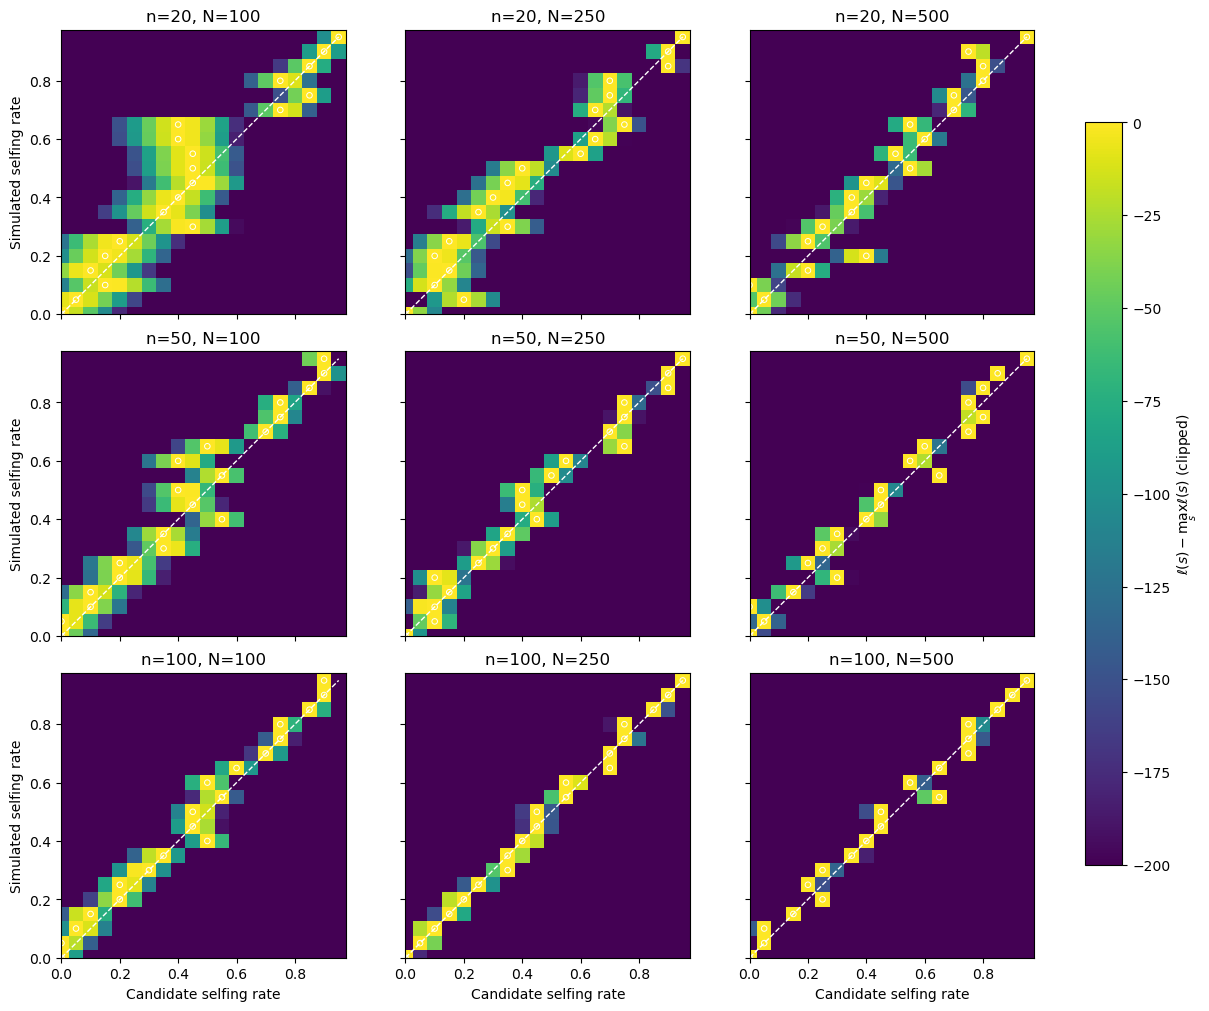

In [2]:
fig, axes = plt.subplots(
    3, 3, figsize=(12, 10), sharex=True, sharey=True, layout="constrained"
)

for row, n in enumerate(SAMPLE_SIZES):
    for column, N in enumerate(POPULATION_SIZES):
        ax = axes[row, column]
        subset = likelihoods[
            (likelihoods["n_diploids"] == n)
            & (likelihoods["census_size"] == N)
        ]
        surface = subset.pivot(
            index="true_s", columns="candidate_s", values="delta_loglik"
        ).reindex(index=SELFING_GRID, columns=SELFING_GRID)
        if surface.isna().any().any():
            raise ValueError(f"Incomplete likelihood grid for n={n}, N={N}")

        image = ax.pcolormesh(
            SELFING_GRID, SELFING_GRID,
            np.clip(surface.to_numpy(), CLIP_FLOOR, 0),
            shading="nearest", cmap="viridis", vmin=CLIP_FLOOR, vmax=0,
        )
        best_s = surface.idxmax(axis=1)
        ax.scatter(
            best_s, surface.index, s=16,
            facecolors="none", edgecolors="white", linewidths=0.7,
        )
        ax.plot([0, 0.95], [0, 0.95], "w--", linewidth=1)
        ax.set(
            title=f"n={n}, N={N}", aspect="equal",
            xlim=(0, 0.975), ylim=(0, 0.975),
        )
        if row == 2:
            ax.set_xlabel("Candidate selfing rate")
        if column == 0:
            ax.set_ylabel("Simulated selfing rate")

colorbar = fig.colorbar(image, ax=axes, shrink=0.8)
colorbar.set_label(r"$\ell(s)-\max_s\ell(s)$ (clipped)")

for extension in ("png", "pdf"):
    fig.savefig(
        RESULTS / f"fixed_individuals_likelihood_heatmap.{extension}",
        dpi=300, bbox_inches="tight",
    )
plt.show()
